In [2]:
%pip install statsmodels
%pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_pickle("bank_09.pkl")

print(data.head())

print(data.shape)

print(data['marital'].value_counts().shape)

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Comenzamos identificandoo las variables categóricas nominales, categóricas ordinales y las variables numéricas.

Realizando un shape, obtenemos que hay 17 variables y 11000 instancias.

Llevamos a cabo un head para ver que valores tienen las diferentes variables (numérico, categórico ordinal o categórico nominal):

- **Variables numéricas**: age, balance, day, duration, campaign, pdays, previous
- **Variables categóricas nominales**: job, default, housing, loan, contact, marital, poutcome, deposit, month
- **Variables categóricas ordinales**: education

In [42]:

lista=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
for item in lista:
    if data[item].value_counts().shape[0] > 10:
        print("Cardinalidad", item, "es", data[item].value_counts().shape[0])

Cardinalidad job es 12
Cardinalidad month es 12


Hacemos una lista en la que incluimos los nombres de todas las variables categóricas. Seguidamente, recorremos dicha lista, comprobando para cada ítem, si su cardinalidad es mayor que 10. De ser así, lo imprimimos.

In [43]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    print("La columna '", item, "' tiene ", (data[item]=="unknown").sum(), "valores unknown")
    print("La columna '", item, "' tiene ", (data[item].isna()).sum(), "valores NULL \n")

La columna ' age ' tiene  0 valores unknown
La columna ' age ' tiene  0 valores NULL 

La columna ' job ' tiene  68 valores unknown
La columna ' job ' tiene  97 valores NULL 

La columna ' marital ' tiene  0 valores unknown
La columna ' marital ' tiene  282 valores NULL 

La columna ' education ' tiene  494 valores unknown
La columna ' education ' tiene  0 valores NULL 

La columna ' default ' tiene  0 valores unknown
La columna ' default ' tiene  0 valores NULL 

La columna ' balance ' tiene  0 valores unknown
La columna ' balance ' tiene  0 valores NULL 

La columna ' housing ' tiene  0 valores unknown
La columna ' housing ' tiene  0 valores NULL 

La columna ' loan ' tiene  0 valores unknown
La columna ' loan ' tiene  0 valores NULL 

La columna ' contact ' tiene  2309 valores unknown
La columna ' contact ' tiene  0 valores NULL 

La columna ' day ' tiene  0 valores unknown
La columna ' day ' tiene  0 valores NULL 

La columna ' month ' tiene  0 valores unknown
La columna ' month ' 

Hacemos un bucle para ver la cantidad de unknowns y NULL que hay en cada columna y obtenemos que las columnas que tienen valores faltantes son:
La columna ' job ' tiene  68 valores unknown
La columna ' job ' tiene  97 valores NULL 
La columna ' marital ' tiene  282 valores NULL 
La columna ' education ' tiene  494 valores unknown
La columna ' contact ' tiene  2309 valores unknown
La columna ' poutcome ' tiene  8205 valores unknown
Se observa que hay muchas filas en las que se desconocen valores o no están escritos ni siquiera

In [44]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    if data[item].value_counts().shape[0] == 1:
        print("Columa constante es:", item)

Hacemos un bucle para comprobar si hay columnas constantes (comprobando si el número de valores posibles que presentan es igual a 1) y obtenemos que no hay ninguna columna constante

In [45]:
lista=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
for item in lista:
    if len(data[item].value_counts()) == data.shape[0]:
        print("Columa ID es:", item)

Hacemos un bucle para comprobar si hay columnas ID (comprobamos si el número de valores posibles que presentan es igual al número de instancias) y obtenemos que no hay ninguna columna ID

Se trata de un problema de clasificación puesto que la variable objetivo "deposit" es una variable categórica

In [46]:
print(data['deposit'].value_counts())

deposit
no     5780
yes    5220
Name: count, dtype: int64


Comprobamos la cantidad de valores que presenta cada clase para la variable "deposit" y podemos observar que no está desbalanceado puesto que hay un número parecido de valores para cada clase

In [47]:
print(data['pdays'].dtype)

print(data['pdays'].value_counts())

int64
pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
        ... 
 651       1
 214       1
 24        1
 701       1
 118       1
Name: count, Length: 472, dtype: int64


La variable "pdays", como hemos mencionado anteriormente, es una variable numérica. Por otro lado, la distribución de valores está bastante descompensada puesto que la mayoría de las filas (alrededor de un 74%) tienen un valor igual a "-1", lo que significa que la mayoría de clientes no han sido contactados o esto es desconocido. Debido a que hay un total de 472 valores distintos y que "-1" representa un 74%, el modelo se vería muy afectado por dicho valor, por lo que es necesario preprocesamiento. Por otro lado, más arriba hemos visto también que "pdays" no tiene ningún valor "unknown", "NULL" o "NaN"

In [48]:
data['contactado_previamente'] = (data['pdays']!= -1).astype(int)
data['pdays'] = data['pdays'].replace(-1, np.nan)

print(data['contactado_previamente'].value_counts())

contactado_previamente
0    8203
1    2797
Name: count, dtype: int64


### **Preprocesado de la variable pdays:**
Para el preprocesado identificamos que la variable pdays aporta dos tipos de información: si la persona ha sido contactada previamente y, en caso afirmativo, cuánto tiempo ha pasado desde ese contacto. Por ello, realizaremos dos operaciones.

En primer lugar, crearemos una nueva variable binaria, contactado_previamente, que tomará el valor 0 si el cliente no ha sido contactado previamente y 1 en caso contrario.
En segundo lugar, sustituiremos los valores -1 de la columna pdays por NaN en la propia columna pdays, ya que -1 no representa una cantidad real de días, sino ausencia de contacto previo o un valor no aplicable.

Con estos cambios obtenemos una representación más correcta de la información original. La variable contactado_previamente recoge si existió o no contacto previo, mientras que la modificación de pdays conserva únicamente los valores válidos de días para aquellos clientes que sí fueron contactados. De este modo, evitamos tratar -1 como un valor numérico ordinario.

In [49]:
filtro = data['poutcome'] == 'unknown'

print("previous cuando poutcome = unknown")
display(data.loc[filtro, 'previous'].value_counts())

print("pdays cuando poutcome = unknown")
display(data.loc[filtro, 'pdays'].value_counts())

previous cuando poutcome = unknown


previous
0    8203
2       1
1       1
Name: count, dtype: int64

pdays cuando poutcome = unknown


pdays
188.0    1
98.0     1
Name: count, dtype: int64

Se ha comprobado que la categoría unknown de la variable poutcome coincide prácticamente en todos los casos con previous = 0 y con pdays = Nan (persona no contactada, que tras el preprocesado pasó de -1 a Nan). En concreto, esto ocurre en 8203 de 8205 casos, por lo que unknown no parece representar un faltante aleatorio, sino una categoría informativa asociada a la ausencia de contactos o campañas previas.

## **APARTADO 3: DECIDIR CÓMO SE VA A HACER LA EVALUACIÓN**

### **Métrica**

Utilizaremos como métrica principal el F1-score, ya que se trata de un problema de clasificación binaria (deposit puede ser yes/no) y esta métrica permite evaluar de forma conjunta la precisión y el recall, siendo más informativa que la accuracy cuando interesa valorar el equilibrio entre ambas.

### **Holdout y partición train/test**

Realizamos la partición **holdout** indicada en el enunciado, usando **2/3 de los datos para train** y **1/3 para test**.  
Esta división se hace de forma **estratificada según `deposit`**, para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

Además, mapeamos la variable objetivo a valores binarios (`0 = no`, `1 = yes`) para trabajar con ella de forma más cómoda posteriormente. Finalmente, comprobamos que la distribución del target se mantiene similar en el conjunto completo, en train y en test.

In [5]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='deposit')
y = data['deposit'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

print("Distribución completa:")
print(y.value_counts(normalize=True))

print("\nDistribución en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True))

Distribución completa:
deposit
0    0.525455
1    0.474545
Name: proportion, dtype: float64

Distribución en train:
deposit
0    0.525433
1    0.474567
Name: proportion, dtype: float64

Distribución en test:
deposit
0    0.525498
1    0.474502
Name: proportion, dtype: float64


### **Evaluación inner**

La mayor parte de la práctica se realizará únicamente sobre el conjunto de entrenamiento. Para comparar alternativas y ajustar hiperparámetros utilizaremos una evaluación interna mediante **Stratified K-Fold con 5 particiones**, ya que se trata de un problema de clasificación y conviene mantener la proporción de clases en cada partición.

In [6]:
from sklearn.model_selection import StratifiedKFold

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)



## **APARTADO 4. MÉTODOS BÁSICOS KNN Y TREES**

### **PREPROCESADO**

Antes de evaluar los distintos métodos, es necesario preprocesar las variables. En vez de transformar cada columna por separado de forma manual, se ha optado por construir un preprocesado conjunto mediante **pipelines y un ColumnTransformer**, de forma que cada tipo de variable reciba automáticamente el tratamiento adecuado. Esto también permite integrar todo el preprocesado dentro del entrenamiento del modelo y evitar problemas de information leakage.

En nuestro caso distinguimos tres grupos de variables:

- Categóricas nominales: job, marital, default, housing, loan, contact, month y poutcome.

- Numéricas: pdays, balance, age, day, duration, campaign y previous.

- Ordinal: education.

Para las variables **categóricas nominales**, se aplica primero una imputación de los valores faltantes mediante *SimpleImputer* con la estrategia *most frequent*, y después una codificación *One-Hot* con *OneHotEncoder*.

Para las **variables numéricas**, se utiliza una imputación mediante la *mediana*, ya que es una medida robusta frente a valores extremos, y después un escalado Min-Max, especialmente útil en métodos como KNN, que se basan en distancias.

Por último, la **variable education** se trata como ordinal, ya que sus categorías siguen un orden natural *(primary < secondary < tertiary)/. Antes de codificarla, los valores unknown se **transforman en valores faltantes**, que posteriormente se imputan con la categoría más frecuente. Después, se aplica una codificación ordinal con OrdinalEncoder.

Finalmente, estas tres transformaciones se combinan en un **ColumnTransformer** y se integran en una **pipeline** final junto con el clasificador KNN, de forma que todo el preprocesado se realiza de manera conjunta y consistente dentro del entrenamiento.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import cross_val_score

# Columnas
categorical_features = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
numerical_features = ['pdays', 'balance', 'age', 'day', 'duration', 'campaign', 'previous']
ordinal_features = ['education']

#Convertimos a missing para luego imputarlo
X_train['education'] = X_train['education'].replace('unknown', pd.NA)
X_test['education'] = X_test['education'].replace('unknown', pd.NA)

#Pipeline categórica nominal
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=pd.NA, strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Pipeline ordinal
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=pd.NA, strategy='most_frequent')),
    ('onehot', OrdinalEncoder(categories=[['primary', 'secondary', 'tertiary']]))
])

scalers = {'MinMaxScaler': MinMaxScaler(), 'RobustScaler': RobustScaler(), 'StandardScaler': StandardScaler()}

resultados = []

for name, scaler in scalers.items():

    #Pipeline numérica
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    
    
    #Preprocesador conjunto
    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', categorical_pipeline, categorical_features),
            ('numerical', numerical_pipeline, numerical_features),
            ('ordinal', ordinal_pipeline, ordinal_features)
        ]
    )
    
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')

    #Guardamos los resultados 
    resultados.append({
        'scaler': name,
        'f1_mean': scores.mean(),
        'f1_std': scores.std()
    })

resultados_df = pd.DataFrame(resultados).sort_values('f1_mean', ascending=False)
display(resultados_df)

,scaler,f1_mean,f1_std
2,StandardScaler,0.787486,0.016217
1,RobustScaler,0.772027,0.017832
0,MinMaxScaler,0.697150,0.009819


Se observa que el mejor escalado es el escalado standard el **StandardScaler**, y es el que usaremos a partir de ahora. Procedemos a definir nuestro final pipe.

In [8]:
from sklearn.tree import DecisionTreeClassifier
import time

methods = {'tree': DecisionTreeClassifier(), 'KNN': KNeighborsClassifier()}

resultados_metodos = []

#Pipeline numérica
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


#Preprocesador conjunto
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, categorical_features),
        ('numerical', numerical_pipeline, numerical_features),
        ('ordinal', ordinal_pipeline, ordinal_features)
    ]
)

for name, method in methods.items():

    final_pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', method)
    ])

    inicio = time.time()

    score_method = cross_val_score(
        final_pipe,
        X_train,
        y_train,
        cv=cv_inner,
        scoring='f1'
    )

    fin = time.time()
    tiempo_total = fin - inicio
    
    resultados_metodos.append({
        'method': name,
        'f1_mean': score_method.mean(),
        'f1_std': score_method.std(),
        'time_sec': tiempo_total
    })

resultados_methods_df = pd.DataFrame(resultados_metodos).sort_values('f1_mean', ascending=False)
display(resultados_methods_df)



,method,f1_mean,f1_std,time_sec
1,KNN,0.787486,0.016217,0.493878
0,tree,0.772805,0.008645,0.265564


En esta primera evaluación con los hiperparámetros por defecto parece que tree es mejor que KNN muy ligeramente. Como se puede observar, con **KNN** obtenemos un mejor rendimiento predictivo (mayor f1_mean). No obstante, el coste computacional es mejor para **tree** pues es 2 veces más rápido y también es más estable (f1_std).  Ahora interpretremos cómo se pueden llevar a cabo decisiones en este problema usando árboles poco profundos:

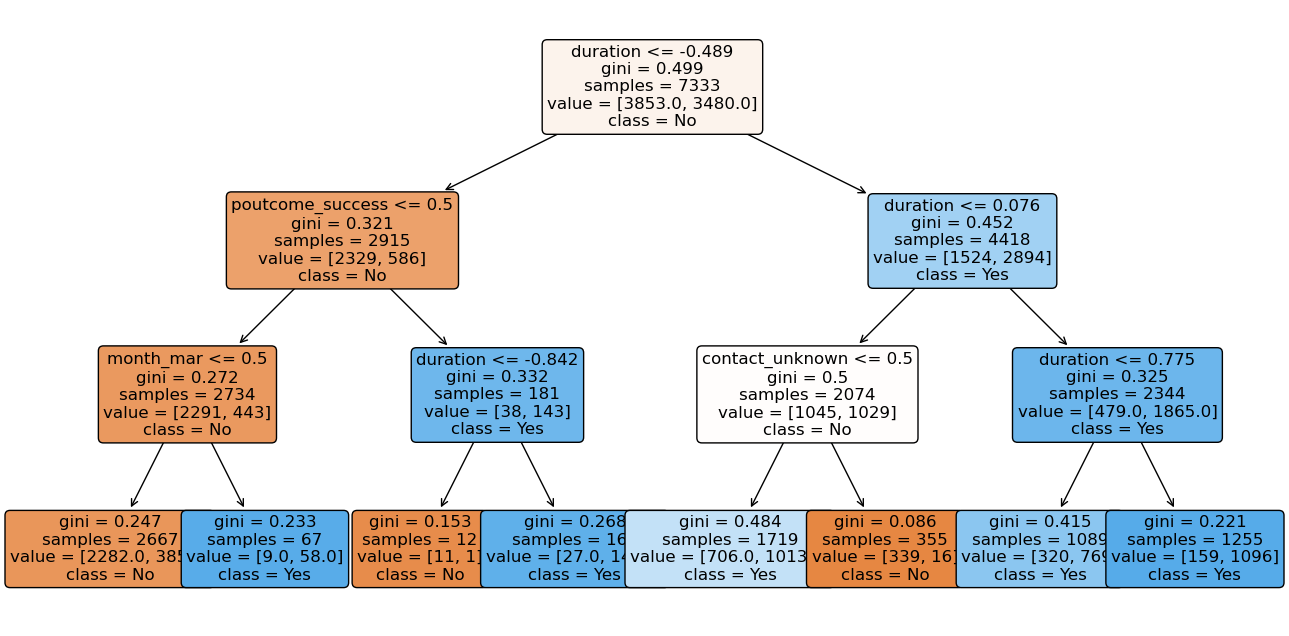

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Entrenamos el árbol sobre los datos transformados
X_train_prepared = preprocessor.fit_transform(X_train)
arbol_interpretable = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_interpretable.fit(X_train_prepared, y_train)

# Extraemos nombres de columnas transformadas desde el ColumnTransformer
feature_names = []

# Iteramos sobre los transformers
for name, transformer, cols in preprocessor.transformers_:
    if name == 'categorical' or name == 'ordinal':
        # OneHotEncoder dentro del pipeline
        ohe = transformer.named_steps[list(transformer.named_steps.keys())[-1]]  # último paso
        names = ohe.get_feature_names_out(cols)
        feature_names.extend(names)
    elif name == 'numerical':
        feature_names.extend(cols)

# Ploteamos
plt.figure(figsize=(16,8))
plot_tree(arbol_interpretable,
          feature_names=feature_names,
          class_names=['No','Yes'],  # Ajusta según tu target
          filled=True,
          rounded=True,
          fontsize=12)
plt.show()

El árbol entrenado indica que la variable más decisiva es la **duración de la llamada**. Si la llamada es muy corta, la probabilidad de depósito es baja. El resultado previo del cliente y si fue contactado antes también influyen. Las hojas muestran claramente la distribución de clases y permiten interpretar de manera sencilla la decisión del modelo. Después de esto, vamos a llevar a cabo **el ajuste de los hiperparámetros**:

In [10]:
from sklearn.model_selection import GridSearchCV
import time

# Creamos GridSearch para KNN
pipe_knn = Pipeline([
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
'model__n_neighbors': [3, 5, 7, 9, 11],
'model__weights': ['uniform', 'distance'],
'model__p': [1, 2]
}

grid_knn = GridSearchCV(estimator=pipe_knn,
                        param_grid=param_grid_knn,
                        cv=cv_inner,
                        scoring='f1',
                        n_jobs=-1)


# Creamos GridSearch para árboles
pipe_tree = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier())
])

param_grid_tree = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(estimator=pipe_tree,
                         param_grid=param_grid_tree,
                         cv=cv_inner,
                         scoring='f1',
                         n_jobs=-1)


# Entrenamos con KNN midiendo el tiempo
inicio = time.time()
grid_knn.fit(X_train, y_train)
fin = time.time()
time_knn = fin - inicio


# Entrenamos con árbol midiendo el tiempo
inicio = time.time()
grid_tree.fit(X_train, y_train)
fin = time.time()
time_tree = fin - inicio


# Guardamos los resultados
resultados_hpo = pd.DataFrame([
    {
        'method': 'KNN',
        'best_f1': grid_knn.best_score_,
        'time_sec': time_knn
    },
    {
        'method': 'Tree',
        'best_f1': grid_tree.best_score_,
        'time_sec': time_tree
    }
])

display(resultados_hpo)

,method,best_f1,time_sec
0,KNN,0.796586,8.096167
1,Tree,0.815044,1.665655


Como se puede observar, el **ajuste de hiperparámetros** mejora el rendimiento, sobretodo en **Tree**. Después de este ajuste, **el árbol de decisión supera a KNN**, dominando **Tree** completamente, pues tiene un mayor rendimiento y un menor coste computacional (tarda mucho menos que **KNN**). Ahora procederemos a explicar, mediante plots, el efecto de los distintos valores de los hiper-parámetros en el resultado final:

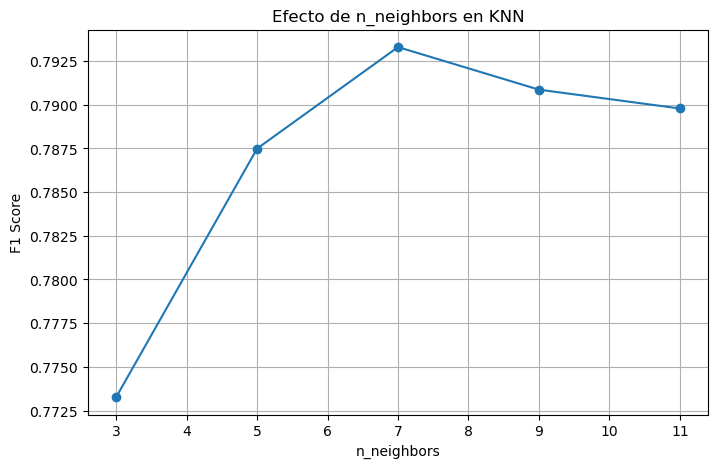

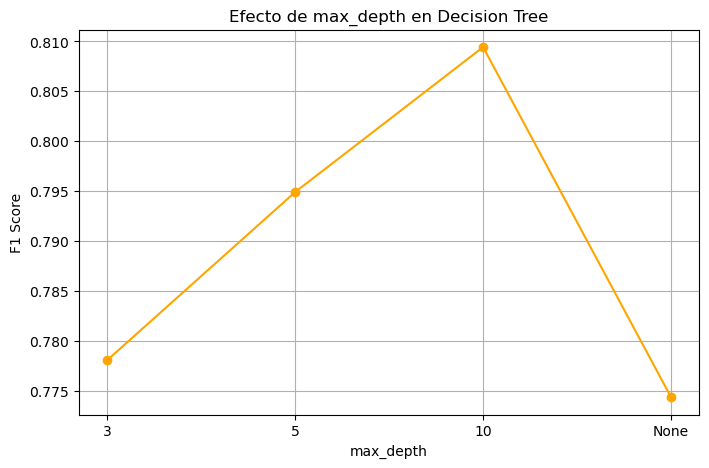

Dummy Classifier F1: 0.0000 ± 0.0000


,method,best_f1,time_sec
0,Dummy,0.000000,0.000000
1,KNN_HPO,0.796586,8.096167
2,Tree_HPO,0.815044,1.665655


In [15]:
from sklearn.dummy import DummyClassifier

# Plots de hiperparámetros para KNN
f1_scores_knn = []

# Solo mostramos el efecto de n_neighbors como ejemplo
for n in [3,5,7,9,11]:
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=n, weights='uniform', p=2))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')
    f1_scores_knn.append(scores.mean())

plt.figure(figsize=(8,5))
plt.plot([3,5,7,9,11], f1_scores_knn, marker='o')
plt.title("Efecto de n_neighbors en KNN")
plt.xlabel("n_neighbors")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


# Plots de hiperparámetros para Árboles
f1_scores_tree = []

for depth in [3, 5, 10, None]:
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1')
    f1_scores_tree.append(scores.mean())

plt.figure(figsize=(8,5))
depth_labels = ['3','5','10','None']
plt.plot(depth_labels, f1_scores_tree, marker='o', color='orange')
plt.title("Efecto de max_depth en Decision Tree")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()


# Comparación con DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_train, y_train, cv=cv_inner, scoring='f1')
print(f"Dummy Classifier F1: {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")


# Resultados finales comparativos
resultados_final = pd.DataFrame([
    {'method': 'Dummy', 'best_f1': dummy_scores.mean(), 'time_sec': 0},
    {'method': 'KNN_HPO', 'best_f1': grid_knn.best_score_, 'time_sec': time_knn},
    {'method': 'Tree_HPO', 'best_f1': grid_tree.best_score_, 'time_sec': time_tree}
])

display(resultados_final)

En conclusión, los modelos evaluados muestran que tanto **KNN** como **Decision Tree** superan ampliamente al **baseline trivial**, indicando que aprenden patrones reales del dataset desbalanceado. El F1 Score de los **árboles** mejora con profundidades moderadas, mientras que **KNN** alcanza su mejor desempeño con un número intermedio de vecinos. Entre ambos, el **Decision Tree** ofrece el mejor balance entre precisión (F1≈0.815), rapidez de entrenamiento y interpretabilidad, mientras que **KNN**, aunque competitivo (F1≈0.797), es más sensible al escalado y más costoso computacionalmente. Por ello, para este problema se recomienda un **árbol de decisión moderadamente profundo como la opción más práctica y eficiente**.